--- Starting Extended Time Series Analysis: TSLA vs. ['MP', 'LAZR', 'VALE', 'MGA', 'PLUG'] ---
Data period: 2021-01-01 to Present | Rolling Window: 60 days

[SECTION 2: DATA ACQUISITION & PREP]


/tmp/ipython-input-4160757235.py:44: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(all_tickers, start=START_DATE, progress=False)['Close']


Final synchronized data points: 1235.
Logarithmic returns calculated and synchronized.

[SECTION 3: VERBOSE STATIONARITY CHECK (ADF TEST on Prices)]
H0: The series is NON-STATIONARY (Unit root exists).
Tests are performed on Price Levels to check for integration order I(1).
--------------------------------------------------------------------------------
Ticker     | ADF Statistic   | P-value    | 1% Critical Value  | I(1) Status
--------------------------------------------------------------------------------
LAZR       | -4.5799         | 0.0001     | -3.4358            | Likely I(0) (Stationary)
MGA        | -1.6693         | 0.4470     | -3.4357            | Likely I(1) (Non-Stationary)
MP         | -1.5281         | 0.5196     | -3.4357            | Likely I(1) (Non-Stationary)
PLUG       | -4.1170         | 0.0009     | -3.4358            | Likely I(0) (Stationary)
TSLA       | -1.9436         | 0.3118     | -3.4357            | Likely I(1) (Non-Stationary)
VALE       | -2.5524    

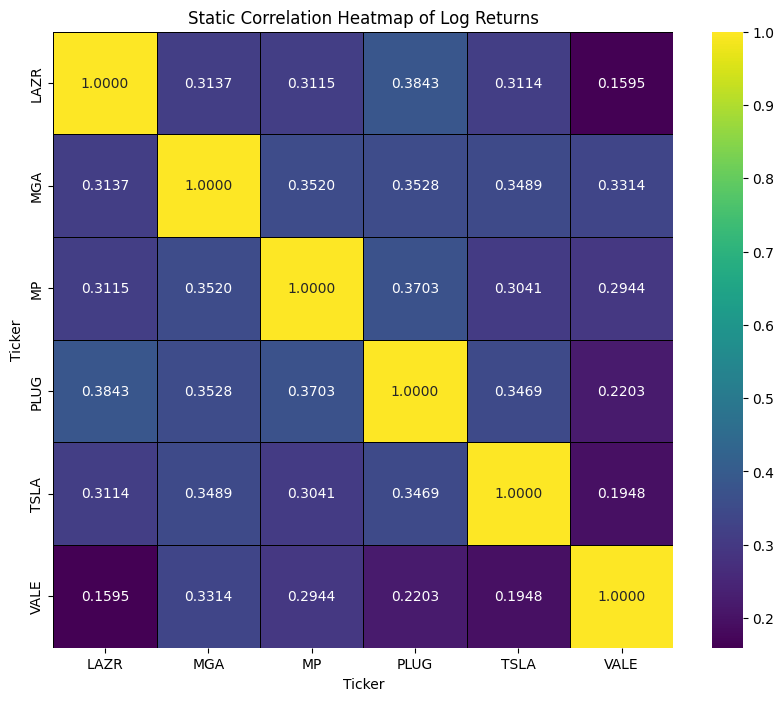

Static correlation heatmap generated.

[SECTION 5: ROLLING CORRELATION ANALYSIS (60-DAY WINDOW)]


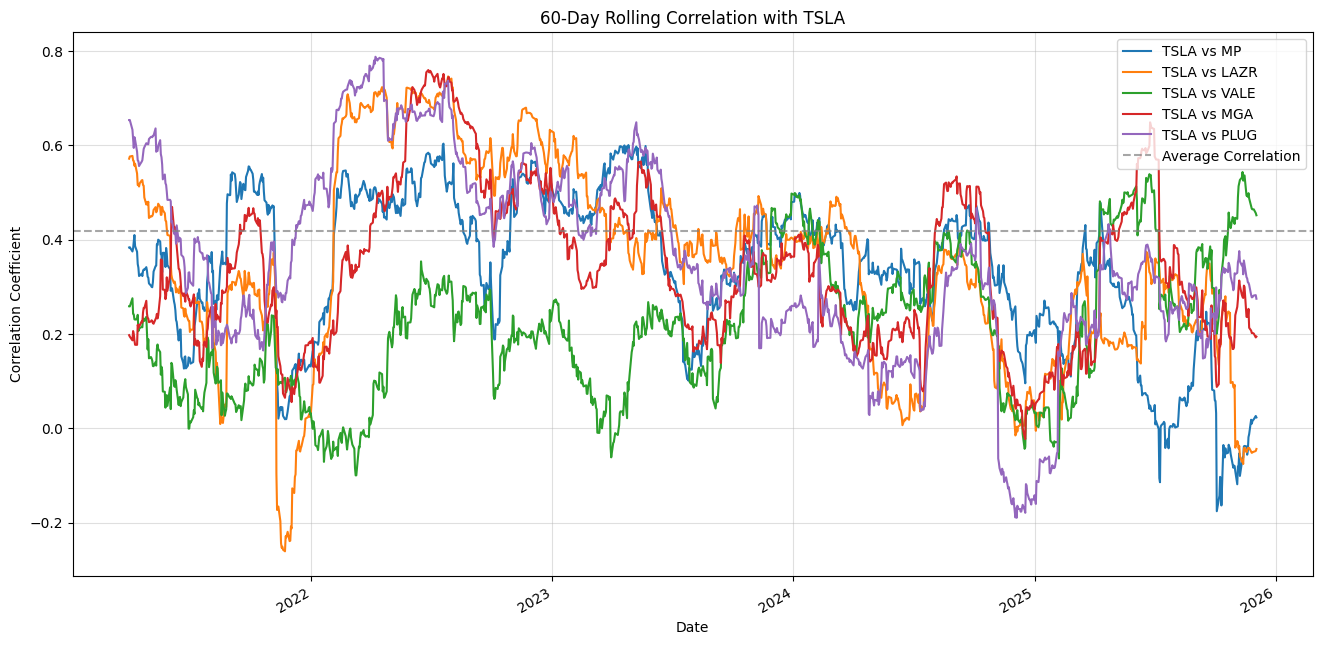

Rolling correlation plot generated.

[SECTION 6: ENGLE-GRANGER COINTEGRATION & RESIDUAL ANALYSIS (Spread Plot)]
Pair: TSLA vs MP | E-G Coint P-Value: 0.1604 (NOT COINTEGRATED)
Pair: TSLA vs LAZR | E-G Coint P-Value: 0.5142 (NOT COINTEGRATED)
Pair: TSLA vs VALE | E-G Coint P-Value: 0.3439 (NOT COINTEGRATED)
Pair: TSLA vs MGA | E-G Coint P-Value: 0.5167 (NOT COINTEGRATED)
Pair: TSLA vs PLUG | E-G Coint P-Value: 0.5519 (NOT COINTEGRATED)


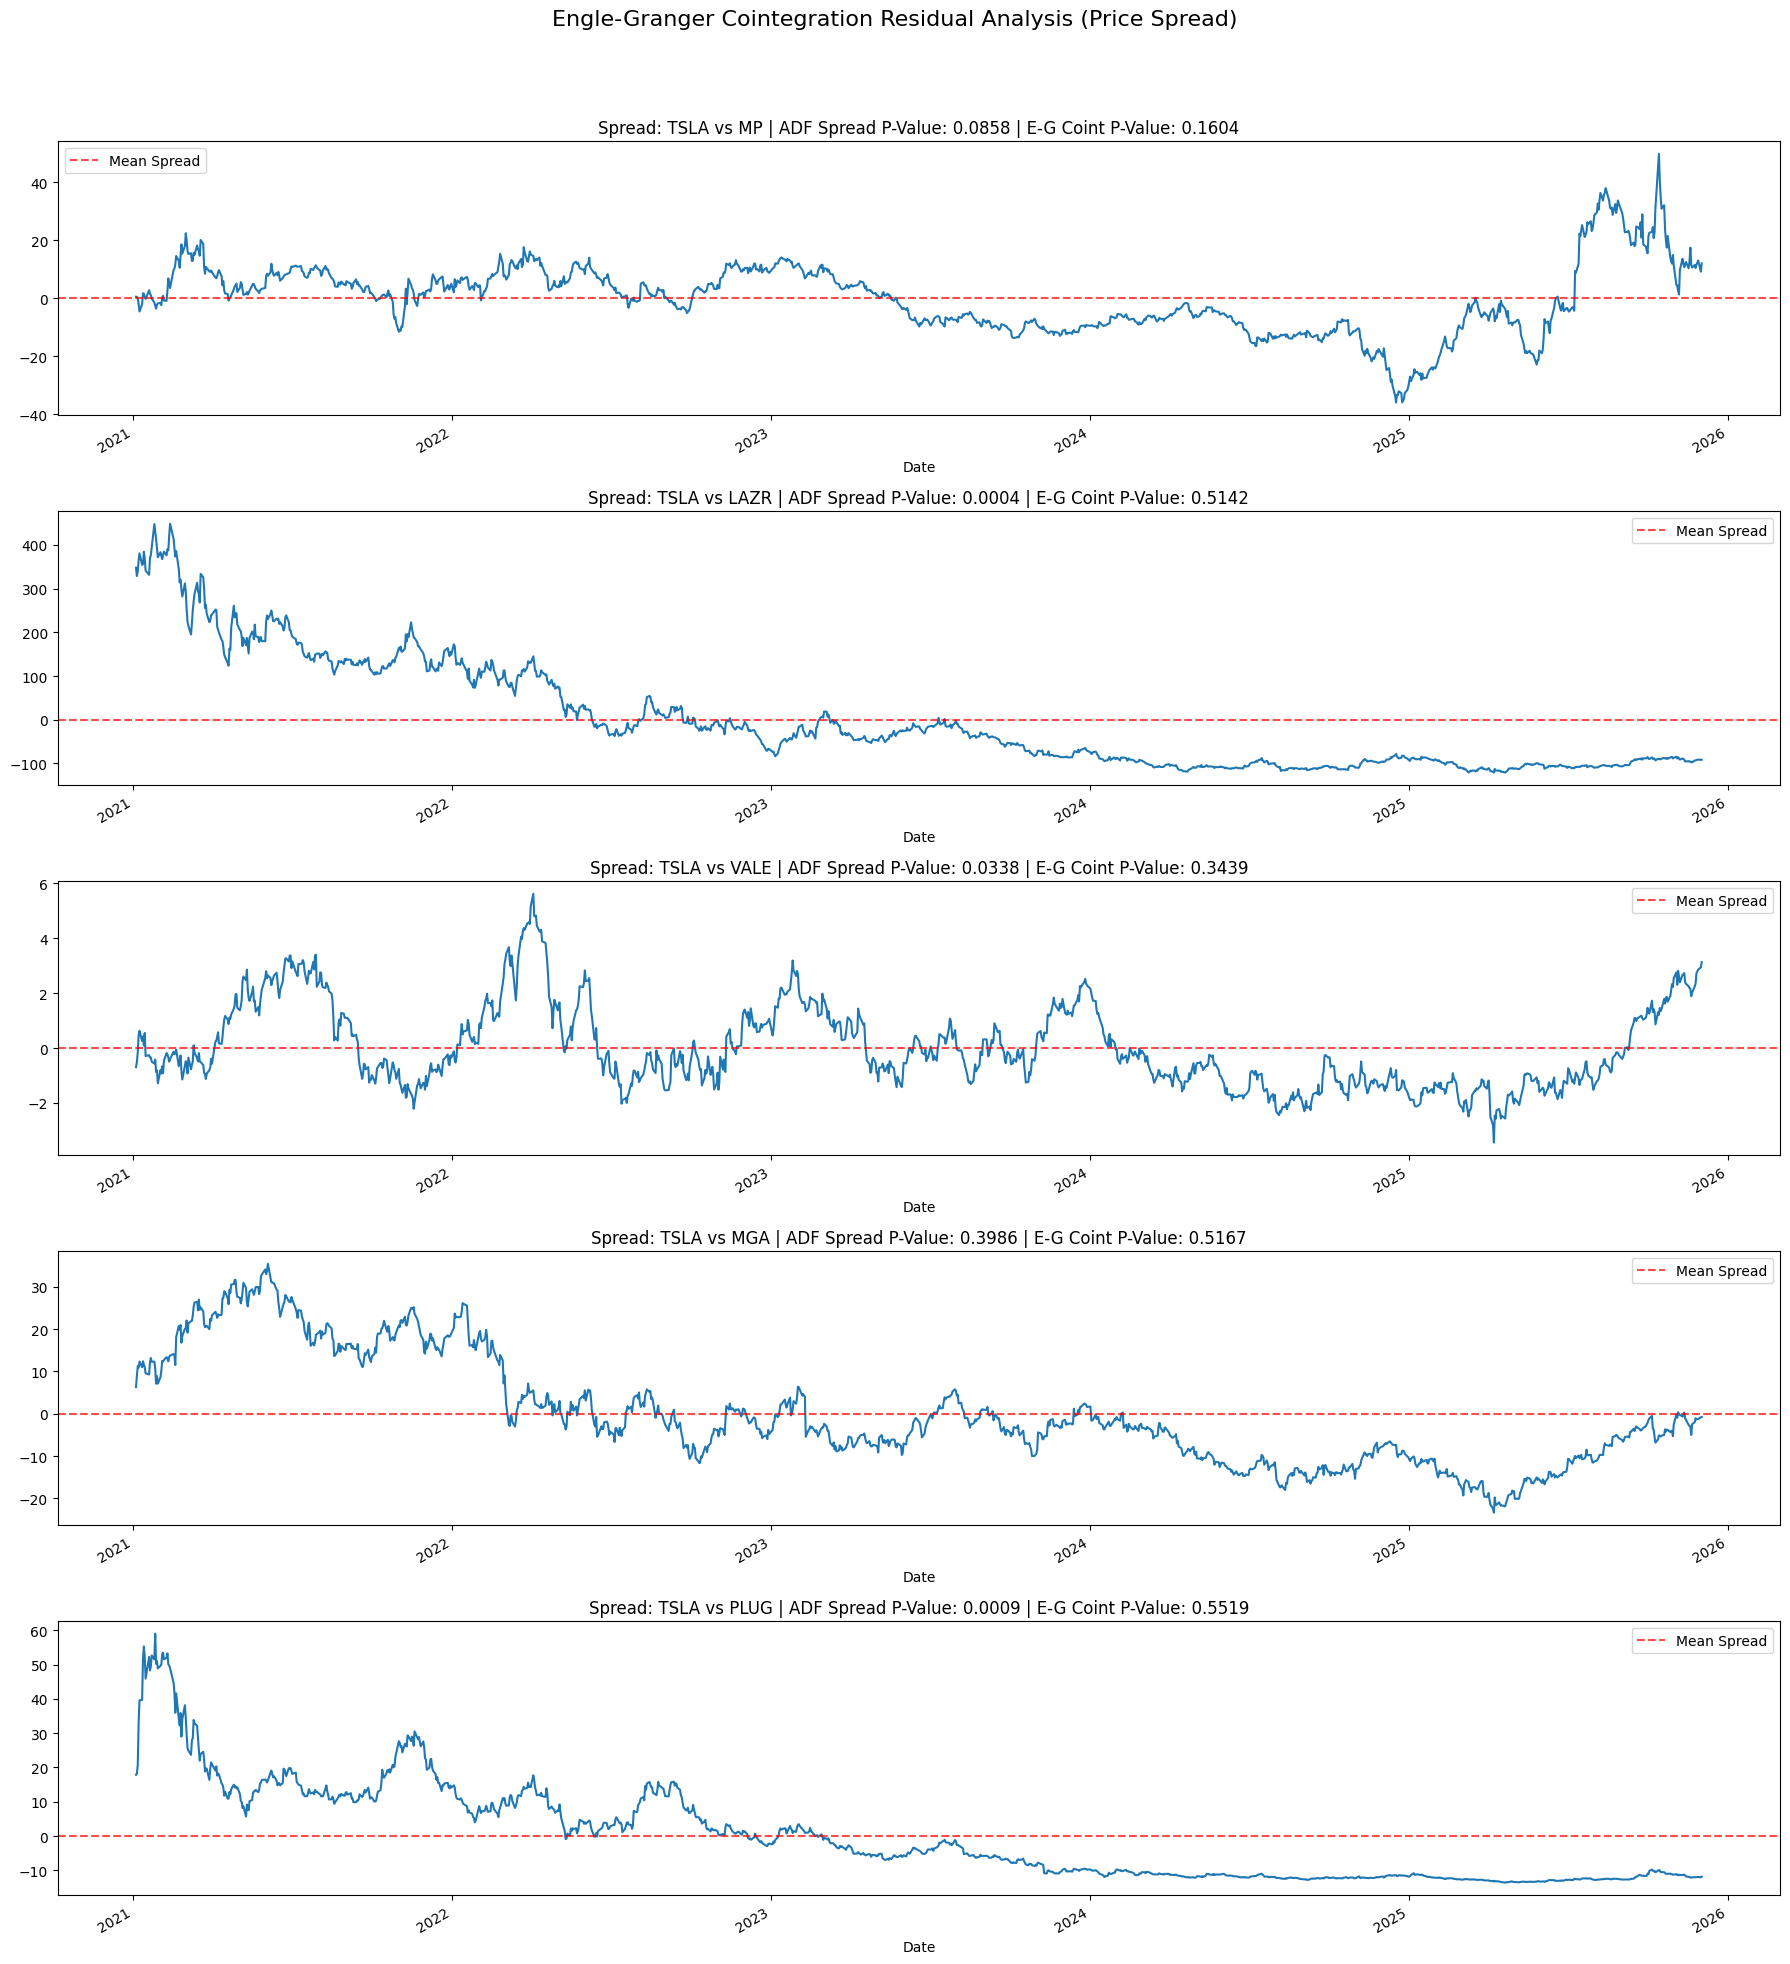


[SECTION 7: GARCH(1,1) CONDITIONAL VOLATILITY MODELING]
--- SKIPPING GARCH: 'arch' library is not installed. Please run '!pip install arch' ---

[SECTION 8: JOHANSEN COINTEGRATION TEST (Multivariate)]
Tests for the number of cointegrating relationships (r) in the entire group.

--- Johansen Test Results ---
H0: Rank is r (Number of cointegrating vectors)
---------------------------------------------------------------------------
Hypothesis r    | Test Statistic  | 95% Critical Value   | Status (Trace Stat)
---------------------------------------------------------------------------
0               | 102.6452        | 95.7542              | Reject H0 (r >= 0)
1               | 50.3248         | 69.8189              | Do Not Reject H0 (r = 1)
2               | 24.9766         | 47.8545              | Do Not Reject H0 (r = 2)
3               | 13.5809         | 29.7961              | Do Not Reject H0 (r = 3)
4               | 5.6899          | 15.4943              | Do Not Reject H0 (r = 

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.api import OLS, add_constant
# Import necessary library for Johansen Test
from statsmodels.tsa.vector_ar.vecm import coint_johansen
# Import necessary library for GARCH (Requires separate installation: !pip install arch)
try:
    from arch import arch_model
except ImportError:
    print("Warning: 'arch' library not found. GARCH section will be skipped.")
    arch_model = None

# ----------------------------------------------------------------------
# STEP 1: DEFINE TARGET TICKERS AND COMPANY DESCRIPTIONS
# ----------------------------------------------------------------------

primary_ticker = 'TSLA'
stock_tickers = ['MP', 'LAZR', 'VALE', 'MGA', 'PLUG']

company_details = {
    'TSLA': "Tesla, Inc.: The dominant electric vehicle (EV) manufacturer and energy storage leader.",
    'MP': "MP Materials Corp.: North America's largest rare earth materials producer, essential for EV magnets.",
    'LAZR': "Luminar Technologies, Inc.: A pure-play LiDAR sensor company, representing the autonomous driving hardware sector.",
    'VALE': "Vale S.A.: A major global miner, focused on key battery components like Nickel and Copper.",
    'MGA': "Magna International Inc.: A leading Tier 1 automotive supplier and contract manufacturer adapting to EV platforms.",
    'PLUG': "Plug Power Inc.: A key player in hydrogen and fuel cell technology, representing the alternative green energy sector."
}

START_DATE = "2021-01-01"
ROLLING_WINDOW = 60 # For rolling correlation
print(f"--- Starting Extended Time Series Analysis: {primary_ticker} vs. {stock_tickers} ---")
print(f"Data period: {START_DATE} to Present | Rolling Window: {ROLLING_WINDOW} days")

# ----------------------------------------------------------------------
# STEP 2: DATA ACQUISITION AND PREPARATION
# ----------------------------------------------------------------------

print("\n[SECTION 2: DATA ACQUISITION & PREP]")
all_tickers = [primary_ticker] + stock_tickers
data = yf.download(all_tickers, start=START_DATE, progress=False)['Close']
df_merged = data.dropna(how='any')

# CRITICAL ERROR CHECK: Check for empty or insufficient data
if df_merged.empty or len(df_merged) < ROLLING_WINDOW:
    print("\n--- CRITICAL ERROR: INSUFFICIENT DATA ---")
    print(f"The synchronized dataset is empty or too small ({len(df_merged)} rows) for rolling analysis.")
    if len(df_merged) < 5:
        raise ValueError("Insufficient data points for analysis after synchronization.")

log_returns = np.log(df_merged / df_merged.shift(1)).dropna()

print(f"Final synchronized data points: {len(df_merged)}.")
print("Logarithmic returns calculated and synchronized.")

# ----------------------------------------------------------------------
# NEW SECTION 3: VERBOSE STATIONARITY CHECK (ADF TEST on Price Levels)
# ----------------------------------------------------------------------

print("\n[SECTION 3: VERBOSE STATIONARITY CHECK (ADF TEST on Prices)]")
print("H0: The series is NON-STATIONARY (Unit root exists).")
print("Tests are performed on Price Levels to check for integration order I(1).")
print("-" * 80)
print(f"{'Ticker':<10} | {'ADF Statistic':<15} | {'P-value':<10} | {'1% Critical Value':<18} | {'I(1) Status'}")
print("-" * 80)

for ticker in df_merged.columns:
    result = adfuller(df_merged[ticker])
    p_value = result[1]

    # Compare test statistic against critical value (stricter than p-value for I(1) check)
    is_i1 = result[0] > result[4]['1%']
    adf_result = "Likely I(1) (Non-Stationary)" if is_i1 else "Likely I(0) (Stationary)"

    print(f"{ticker:<10} | {result[0]:<15.4f} | {p_value:<10.4f} | {result[4]['1%']:<18.4f} | {adf_result}")

print("-" * 80)
print("Conclusion: If prices are I(1), proceed with Cointegration Tests.")

# ----------------------------------------------------------------------
# SECTION 4: CORRELATION ANALYSIS & HEATMAP (Log Returns)
# ----------------------------------------------------------------------

print("\n[SECTION 4: STATIC CORRELATION ANALYSIS]")

correlation_matrix = log_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt='.4f', linewidths=0.5, linecolor='black')
plt.title('Static Correlation Heatmap of Log Returns')
plt.show()
print("Static correlation heatmap generated.")

# ----------------------------------------------------------------------
# SECTION 5: ROLLING CORRELATION ANALYSIS
# ----------------------------------------------------------------------

print("\n[SECTION 5: ROLLING CORRELATION ANALYSIS (60-DAY WINDOW)]")

if len(log_returns) < ROLLING_WINDOW:
    print(f"--- SKIPPING ROLLING ANALYSIS: Data length ({len(log_returns)}) is less than the required window ({ROLLING_WINDOW}). ---")
else:
    plt.figure(figsize=(16, 8))
    tsla_returns = log_returns[primary_ticker]

    for s in stock_tickers:
        rolling_corr = tsla_returns.rolling(window=ROLLING_WINDOW).corr(log_returns[s])
        rolling_corr.plot(label=f'{primary_ticker} vs {s}')

    plt.axhline(log_returns.corr().loc[primary_ticker].mean(), color='grey', linestyle='--', alpha=0.7, label='Average Correlation')
    plt.title(f'{ROLLING_WINDOW}-Day Rolling Correlation with {primary_ticker}')
    plt.xlabel("Date")
    plt.ylabel("Correlation Coefficient")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.4)
    plt.show()
    print("Rolling correlation plot generated.")

# ----------------------------------------------------------------------
# SECTION 6: ENGLE-GRANGER COINTEGRATION & RESIDUAL ANALYSIS
# ----------------------------------------------------------------------

print("\n[SECTION 6: ENGLE-GRANGER COINTEGRATION & RESIDUAL ANALYSIS (Spread Plot)]")

tsla_close = df_merged[primary_ticker]
NUM_PLOTS = len(stock_tickers)

plt.figure(figsize=(18, 4 * NUM_PLOTS))
plt.suptitle('Engle-Granger Cointegration Residual Analysis (Price Spread)', fontsize=16)

if len(df_merged) < 5:
    print("--- SKIPPING COINTEGRATION ANALYSIS: Data length is too short for meaningful OLS regression. ---")
else:
    for i, s in enumerate(stock_tickers):
        try:
            # 1. Run OLS Regression & Calculate spread
            s_close = df_merged[s]
            X = add_constant(tsla_close)
            model = OLS(s_close, X).fit()
            spread = s_close - (model.params['const'] + model.params[primary_ticker] * tsla_close)

            # 2. Perform ADF and Cointegration Test
            adf_spread_result = adfuller(spread)
            adf_pvalue = adf_spread_result[1]
            score, pvalue, _ = coint(tsla_close, s_close)

            # 3. Plotting the Spread
            ax = plt.subplot(NUM_PLOTS, 1, i + 1)
            spread.plot(ax=ax, title=f'Spread: {primary_ticker} vs {s}')
            ax.axhline(spread.mean(), color='red', linestyle='--', alpha=0.7, label='Mean Spread')
            ax.legend(loc='best')

            plt.title(f'Spread: {primary_ticker} vs {s} | ADF Spread P-Value: {adf_pvalue:.4f} | E-G Coint P-Value: {pvalue:.4f}')

            # Final Cointegration Status
            status = "COINTEGRATED" if pvalue < 0.05 else "NOT COINTEGRATED"
            print(f"Pair: {primary_ticker} vs {s} | E-G Coint P-Value: {pvalue:.4f} ({status})")

        except Exception as e:
            print(f"--- WARNING: E-G analysis failed for {s}. Error: {e} ---")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ----------------------------------------------------------------------
# NEW SECTION 7: GARCH(1,1) CONDITIONAL VOLATILITY MODELING
# ----------------------------------------------------------------------

print("\n[SECTION 7: GARCH(1,1) CONDITIONAL VOLATILITY MODELING]")

if arch_model is None:
    print("--- SKIPPING GARCH: 'arch' library is not installed. Please run '!pip install arch' ---")
else:
    # Model the volatility for the primary ticker (TSLA)
    tsla_returns_scaled = log_returns[primary_ticker] * 100 # Scale returns for better model fitting

    # Set up GARCH(1,1) model with student's t distribution (common for financial data)
    am = arch_model(tsla_returns_scaled, vol='Garch', p=1, q=1, mean='Constant', dist='t')
    res = am.fit(disp='off')

    print("\n--- GARCH(1,1) Model Summary for TSLA Log Returns ---")
    print(res.summary())

    # Plotting the conditional volatility
    fig = res.plot(annualize='D') # Plot daily annualized volatility
    fig.set_size_inches(16, 6)
    fig.suptitle(f'{primary_ticker} (TSLA) GARCH(1,1) Conditional Volatility', fontsize=16)
    plt.show()
    print("TSLA GARCH volatility plot generated.")

# ----------------------------------------------------------------------
# NEW SECTION 8: JOHANSEN COINTEGRATION TEST (Multivariate)
# ----------------------------------------------------------------------

print("\n[SECTION 8: JOHANSEN COINTEGRATION TEST (Multivariate)]")
print("Tests for the number of cointegrating relationships (r) in the entire group.")

# Check for required data length for Johansen test (often needs > 100 observations)
if len(df_merged) < 100:
    print(f"--- SKIPPING JOHANSEN TEST: Data length ({len(df_merged)} rows) is too short. Needs > 100. ---")
else:
    # Use only the price levels for the test
    data_for_johansen = df_merged[all_tickers]

    # Determine optimal lag length (often 1 or 2 for financial data; here we use 1 for simplicity)
    # k_ar_diff is the number of lagged differences to include
    johansen_result = coint_johansen(data_for_johansen, det_order=0, k_ar_diff=1)

    # Johansen test outputs Trace and Max Eigenvalue statistics

    print("\n--- Johansen Test Results ---")
    print("H0: Rank is r (Number of cointegrating vectors)")
    print("-" * 75)
    print(f"{'Hypothesis r':<15} | {'Test Statistic':<15} | {'95% Critical Value':<20} | {'Status (Trace Stat)'}")
    print("-" * 75)

    # Display Trace Statistic results
    for i in range(data_for_johansen.shape[1]):
        trace_stat = johansen_result.lr1[i]
        critical_value = johansen_result.cvt[i][1] # 95% critical value

        status = "Reject H0 (r >= {})".format(i) if trace_stat > critical_value else "Do Not Reject H0 (r = {})".format(i)

        print(f"{i:<15} | {trace_stat:<15.4f} | {critical_value:<20.4f} | {status}")

    print("-" * 75)
    print("Conclusion: The first 'Do Not Reject H0' indicates the number of cointegrating vectors (r).")


# ----------------------------------------------------------------------
# SECTION 9: HURST EXPONENT ANALYSIS (LONG-TERM MEMORY)
# ----------------------------------------------------------------------

# Define the Hurst Exponent function again for a standalone section
def hurst_exponent(ts):
    """Calculates the Hurst Exponent for a time series."""
    lags = [2**j for j in range(2, 11)]
    tau = []
    lag_R = []

    for t in lags:
        delta_T = np.subtract(ts[t:], ts[:-t])
        Z = np.cumsum(delta_T - np.mean(delta_T))
        R_S = np.max(Z) - np.min(Z)

        if R_S == 0: continue

        tau.append(np.log(t))
        lag_R.append(np.log(R_S / np.std(delta_T)))

    if len(tau) < 2: return np.nan

    poly = np.polyfit(tau, lag_R, 1)
    H = poly[0]
    return H

print("\n[SECTION 9: HURST EXPONENT ANALYSIS (LONG-TERM MEMORY)]")

if len(df_merged) < 5:
    print("--- SKIPPING HURST ANALYSIS: Data length is too short. ---")
else:
    print("-" * 65)
    print(f"{'Pair':<20} | {'Hurst Exponent':<15} | {'Pattern':<25}")
    print("-" * 65)
    for s in stock_tickers:
        try:
            # Recalculate Spread (Residuals)
            s_close = df_merged[s]
            X = add_constant(tsla_close)
            model = OLS(s_close, X).fit()
            spread = s_close - (model.params['const'] + model.params[primary_ticker] * tsla_close)

            # Calculate Hurst Exponent on the Spread
            H = hurst_exponent(spread.values)

            # Determine Pattern
            if H < 0.45:
                pattern = "STRONG MEAN-REVERTING (Good)"
            elif 0.45 <= H <= 0.55:
                pattern = "RANDOM WALK / WEAK"
            else:
                pattern = "TREND-FOLLOWING (Bad for Pairs)"

            print(f"{primary_ticker} vs {s:<15} | {H:<15.4f} | {pattern}")

        except Exception as e:
            print(f"--- WARNING: Hurst analysis failed for {s}. Error: {e} ---")

print("-" * 65)


# ----------------------------------------------------------------------
# FINAL SUMMARY
# ----------------------------------------------------------------------
print("\n[FINAL SUMMARY]")
print("Analysis concluded. This comprehensive script now includes detailed stationarity checks, static and dynamic correlation, both Engle-Granger and Johansen cointegration tests, volatility modeling, and Hurst Exponent pattern analysis.")